# Notebook profesional: detección, seguimiento, conteo y alertas

Este cuaderno implementa una versión más completa para webcam con:
- detección de personas con YOLOv8
- seguimiento con IDs persistentes
- conteo de entrada y salida por cruce de línea
- grabación de video anotado
- alertas en tiempo real
- métricas por frame y resumen final
- exportación a CSV


In [1]:
# ==========================================================
# CELDA 1: Instalación sugerida dentro de Jupyter
# Ejecutar solo en caso necesario
# ==========================================================

# !pip install ultralytics opencv-python pandas numpy matplotlib


In [2]:
# ==========================================================
# CELDA 2: Importación de librerías
# Base de procesamiento para video, tracking y métricas
# ==========================================================

import cv2
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque, defaultdict
from ultralytics import YOLO


In [3]:
# ==========================================================
# CELDA 3: Parámetros generales del sistema
# Configuración principal para cámara, modelo y salida
# ==========================================================

MODEL_NAME = "yolov8n.pt"
CAMERA_INDEX = 0
CONF_THRESHOLD = 0.40
IOU_THRESHOLD = 0.45
FRAME_WIDTH = 1280
FRAME_HEIGHT = 720
PERSON_CLASS_ID = 0

WINDOW_NAME = "Sistema Profesional de Deteccion de Personas"
OUTPUT_VIDEO = "salida_deteccion_personas_profesional.mp4"
OUTPUT_CSV = "metricas_deteccion_personas_profesional.csv"

USE_TRACKING = True
USE_RECORDING = True
MAX_TRAIL = 30

LINE_MODE = "horizontal"
LINE_POSITION_RATIO = 0.50

ALERT_MAX_PERSONS = 3
ALERT_MIN_CONF = 0.75
ALERT_COOLDOWN_SEC = 2.0


In [4]:
# ==========================================================
# CELDA 4: Estructuras de estado
# Almacenamiento de historiales, IDs, conteos y alertas
# ==========================================================

metricas_por_frame = []

historial_centros = defaultdict(list)
ultimo_lado = {}
ids_contados_entrada = set()
ids_contados_salida = set()

conteo_entrada = 0
conteo_salida = 0
total_frames = 0
total_detecciones = 0

fps_hist = deque(maxlen=30)
inf_hist = deque(maxlen=30)

ultima_alerta_tiempo = 0.0
ultima_alerta_texto = "Sin alertas"

inicio_global = time.time()


In [5]:
# ==========================================================
# CELDA 5: Funciones geométricas y de apoyo
# Cálculo de línea de conteo, lado relativo y dibujo visual
# ==========================================================

def obtener_linea(frame_shape, mode="horizontal", ratio=0.5):
    h, w = frame_shape[:2]
    if mode == "horizontal":
        y = int(h * ratio)
        return (0, y), (w, y)
    x = int(w * ratio)
    return (x, 0), (x, h)


def obtener_lado(cx, cy, frame_shape, mode="horizontal", ratio=0.5):
    h, w = frame_shape[:2]
    if mode == "horizontal":
        y_line = int(h * ratio)
        return "arriba" if cy < y_line else "abajo"
    x_line = int(w * ratio)
    return "izquierda" if cx < x_line else "derecha"


def verificar_cruce(track_id, lado_anterior, lado_actual, mode="horizontal"):
    if lado_anterior is None or lado_actual is None:
        return None

    if mode == "horizontal":
        if lado_anterior == "arriba" and lado_actual == "abajo":
            return "entrada"
        if lado_anterior == "abajo" and lado_actual == "arriba":
            return "salida"
    else:
        if lado_anterior == "izquierda" and lado_actual == "derecha":
            return "entrada"
        if lado_anterior == "derecha" and lado_actual == "izquierda":
            return "salida"

    return None


def dibujar_linea_conteo(frame, mode="horizontal", ratio=0.5):
    p1, p2 = obtener_linea(frame.shape, mode, ratio)
    cv2.line(frame, p1, p2, (255, 255, 0), 2)
    cv2.putText(
        frame,
        "Linea de conteo",
        (p1[0] + 20, p1[1] - 10 if mode == "horizontal" else 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 0),
        2
    )


def dibujar_caja(frame, x1, y1, x2, y2, texto, color=(0, 255, 0), grosor=2):
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, grosor)
    cv2.putText(
        frame,
        texto,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )


def dibujar_centro_y_trayectoria(frame, track_id, cx, cy, historial, color=(0, 128, 255)):
    cv2.circle(frame, (cx, cy), 4, color, -1)

    puntos = historial.get(track_id, [])
    for i in range(1, len(puntos)):
        cv2.line(frame, puntos[i - 1], puntos[i], color, 2)


In [6]:
# ==========================================================
# CELDA 6: Funciones de métricas y alertas
# Resumen estadístico y control de mensajes en tiempo real
# ==========================================================

def calcular_resumen(metricas_df):
    if metricas_df.empty:
        return {
            "frames_procesados": 0,
            "detecciones_totales": 0,
            "fps_promedio": 0.0,
            "tiempo_inferencia_promedio_ms": 0.0,
            "personas_promedio_por_frame": 0.0,
            "confianza_promedio": 0.0,
            "entrada_total": 0,
            "salida_total": 0
        }

    conf_validas = metricas_df["confianza_promedio_frame"].dropna()

    return {
        "frames_procesados": int(len(metricas_df)),
        "detecciones_totales": int(metricas_df["cantidad_personas"].sum()),
        "fps_promedio": float(metricas_df["fps"].mean()),
        "tiempo_inferencia_promedio_ms": float(metricas_df["tiempo_inferencia_ms"].mean()),
        "personas_promedio_por_frame": float(metricas_df["cantidad_personas"].mean()),
        "confianza_promedio": float(conf_validas.mean()) if not conf_validas.empty else 0.0,
        "entrada_total": int(metricas_df["conteo_entrada"].max()) if not metricas_df.empty else 0,
        "salida_total": int(metricas_df["conteo_salida"].max()) if not metricas_df.empty else 0
    }


def generar_alerta(cantidad_personas, confianza_promedio_frame, cooldown_sec=2.0):
    global ultima_alerta_tiempo, ultima_alerta_texto

    ahora = time.time()
    nueva_alerta = None

    if cantidad_personas >= ALERT_MAX_PERSONS:
        nueva_alerta = f"ALERTA: densidad alta de personas ({cantidad_personas})"
    elif not math.isnan(confianza_promedio_frame) and confianza_promedio_frame >= ALERT_MIN_CONF:
        nueva_alerta = f"ALERTA: deteccion confiable ({confianza_promedio_frame:.2f})"

    if nueva_alerta is not None and (ahora - ultima_alerta_tiempo) >= cooldown_sec:
        ultima_alerta_tiempo = ahora
        ultima_alerta_texto = nueva_alerta

    return ultima_alerta_texto


def dibujar_panel(frame, fps_actual, tiempo_inf_ms, cantidad_personas, conf_prom, conteo_entrada, conteo_salida, alerta_texto):
    textos = [
        f"FPS: {fps_actual:.2f}",
        f"Inferencia: {tiempo_inf_ms:.2f} ms",
        f"Personas actuales: {cantidad_personas}",
        f"Confianza promedio: {conf_prom:.2f}" if not math.isnan(conf_prom) else "Confianza promedio: N/A",
        f"Entrada: {conteo_entrada}",
        f"Salida: {conteo_salida}",
        alerta_texto
    ]

    y = 30
    for i, texto in enumerate(textos):
        color = (0, 255, 255)
        if "ALERTA" in texto:
            color = (0, 0, 255)

        cv2.putText(
            frame,
            texto,
            (20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            color,
            2
        )
        y += 32


In [7]:
# ==========================================================
# CELDA 7: Carga del modelo
# Descarga automática del peso en la primera ejecución
# ==========================================================

modelo = YOLO(MODEL_NAME)
print(f"Modelo cargado correctamente: {MODEL_NAME}")


Modelo cargado correctamente: yolov8n.pt


In [8]:
# ==========================================================
# CELDA 8: Inicialización de la cámara y grabación
# Preparación de captura y archivo de salida
# ==========================================================

cap = cv2.VideoCapture(CAMERA_INDEX)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, FRAME_WIDTH)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, FRAME_HEIGHT)

if not cap.isOpened():
    raise RuntimeError("No fue posible acceder a la cámara.")

writer = None

if USE_RECORDING:
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        OUTPUT_VIDEO,
        fourcc,
        20.0,
        (FRAME_WIDTH, FRAME_HEIGHT)
    )

print("Sistema inicializado correctamente.")
print("Tecla Q: finalizar captura")


Sistema inicializado correctamente.
Tecla Q: finalizar captura


In [9]:
# ==========================================================
# CELDA 9: Bucle principal con detección, tracking y conteo
# Conteo por cruce de línea y registro de métricas avanzadas
# ==========================================================

while True:
    tiempo_frame_inicio = time.time()
    ret, frame = cap.read()

    if not ret:
        print("No fue posible leer un frame desde la cámara.")
        break

    inicio_inferencia = time.time()

    resultados = modelo.track(
        source=frame,
        persist=True,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        classes=[PERSON_CLASS_ID],
        verbose=False
    )

    fin_inferencia = time.time()
    tiempo_inferencia_ms = (fin_inferencia - inicio_inferencia) * 1000.0

    cantidad_personas = 0
    confianzas_frame = []

    dibujar_linea_conteo(frame, mode=LINE_MODE, ratio=LINE_POSITION_RATIO)

    if len(resultados) > 0:
        resultado = resultados[0]

        if resultado.boxes is not None and len(resultado.boxes) > 0:
            boxes_xyxy = resultado.boxes.xyxy.cpu().numpy()

            clases = resultado.boxes.cls.cpu().numpy() if resultado.boxes.cls is not None else np.array([])
            confs = resultado.boxes.conf.cpu().numpy() if resultado.boxes.conf is not None else np.array([])
            ids = resultado.boxes.id.cpu().numpy().astype(int) if resultado.boxes.id is not None else np.array([-1] * len(boxes_xyxy))

            for box, clase, confianza, track_id in zip(boxes_xyxy, clases, confs, ids):
                if int(clase) != PERSON_CLASS_ID:
                    continue

                x1, y1, x2, y2 = map(int, box.tolist())
                cx = int((x1 + x2) / 2)
                cy = int((y1 + y2) / 2)

                cantidad_personas += 1
                confianzas_frame.append(float(confianza))

                historial_centros[track_id].append((cx, cy))
                if len(historial_centros[track_id]) > MAX_TRAIL:
                    historial_centros[track_id] = historial_centros[track_id][-MAX_TRAIL:]

                lado_actual = obtener_lado(cx, cy, frame.shape, mode=LINE_MODE, ratio=LINE_POSITION_RATIO)
                lado_anterior = ultimo_lado.get(track_id, None)
                evento = verificar_cruce(track_id, lado_anterior, lado_actual, mode=LINE_MODE)

                if evento == "entrada" and track_id not in ids_contados_entrada:
                    conteo_entrada += 1
                    ids_contados_entrada.add(track_id)

                if evento == "salida" and track_id not in ids_contados_salida:
                    conteo_salida += 1
                    ids_contados_salida.add(track_id)

                ultimo_lado[track_id] = lado_actual

                etiqueta = f"ID {track_id} | Persona | {float(confianza):.2f}"
                dibujar_caja(frame, x1, y1, x2, y2, etiqueta)
                dibujar_centro_y_trayectoria(frame, track_id, cx, cy, historial_centros)

    tiempo_frame_fin = time.time()
    tiempo_total_frame = tiempo_frame_fin - tiempo_frame_inicio
    fps_actual = 1.0 / tiempo_total_frame if tiempo_total_frame > 0 else 0.0

    fps_hist.append(fps_actual)
    inf_hist.append(tiempo_inferencia_ms)

    confianza_promedio_frame = float(np.mean(confianzas_frame)) if len(confianzas_frame) > 0 else float("nan")
    total_frames += 1
    total_detecciones += cantidad_personas

    alerta_texto = generar_alerta(
        cantidad_personas=cantidad_personas,
        confianza_promedio_frame=confianza_promedio_frame,
        cooldown_sec=ALERT_COOLDOWN_SEC
    )

    metricas_por_frame.append({
        "frame_id": total_frames,
        "timestamp_seg": round(time.time() - inicio_global, 3),
        "fps": round(fps_actual, 4),
        "tiempo_inferencia_ms": round(tiempo_inferencia_ms, 4),
        "cantidad_personas": int(cantidad_personas),
        "confianza_promedio_frame": round(confianza_promedio_frame, 4) if not math.isnan(confianza_promedio_frame) else np.nan,
        "conteo_entrada": int(conteo_entrada),
        "conteo_salida": int(conteo_salida),
        "alerta": alerta_texto
    })

    dibujar_panel(
        frame,
        fps_actual=fps_actual,
        tiempo_inf_ms=tiempo_inferencia_ms,
        cantidad_personas=cantidad_personas,
        conf_prom=confianza_promedio_frame,
        conteo_entrada=conteo_entrada,
        conteo_salida=conteo_salida,
        alerta_texto=alerta_texto
    )

    if writer is not None:
        writer.write(frame)

    cv2.imshow(WINDOW_NAME, frame)

    tecla = cv2.waitKey(1) & 0xFF
    if tecla == ord("q"):
        break


requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.9 MB/s  0:00:00

requirements: AutoUpdate success ✅ 1.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points


In [10]:
# ==========================================================
# CELDA 10: Liberación de recursos
# Cierre de cámara, grabación y ventanas de OpenCV
# ==========================================================

cap.release()

if writer is not None:
    writer.release()

cv2.destroyAllWindows()

print("Procesamiento finalizado correctamente.")


Procesamiento finalizado correctamente.


In [11]:
# ==========================================================
# CELDA 11: Construcción del DataFrame y exportación
# Guardado de métricas detalladas por frame
# ==========================================================

df_metricas = pd.DataFrame(metricas_por_frame)
df_metricas.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print("Archivo CSV generado correctamente.")
print(f"CSV: {Path(OUTPUT_CSV).resolve()}")
print(f"Video: {Path(OUTPUT_VIDEO).resolve() if USE_RECORDING else 'Grabacion desactivada'}")
display(df_metricas.head())


Archivo CSV generado correctamente.
CSV: /Users/dev/Downloads/BASESDEDATOS2/laboratorio18abrilsegundo/metricas_deteccion_personas_profesional.csv
Video: /Users/dev/Downloads/BASESDEDATOS2/laboratorio18abrilsegundo/salida_deteccion_personas_profesional.mp4


,frame_id,timestamp_seg,fps,tiempo_inferencia_ms,cantidad_personas,confianza_promedio_frame,conteo_entrada,conteo_salida,alerta
0,1,11.454,0.4195,2372.3371,4,0.5900,0,0,ALERTA: densidad alta de personas (4)
1,2,11.599,21.1395,42.4068,1,0.8120,0,0,ALERTA: densidad alta de personas (4)
2,3,11.691,17.4244,32.0861,4,0.7159,0,0,ALERTA: densidad alta de personas (4)
3,4,11.754,22.7583,30.1540,3,0.7851,0,0,ALERTA: densidad alta de personas (4)
4,5,11.823,20.2863,30.4422,3,0.7757,0,0,ALERTA: densidad alta de personas (4)


In [12]:
# ==========================================================
# CELDA 12: Resumen final del sistema
# Estadísticas globales de detección y conteo
# ==========================================================

resumen = calcular_resumen(df_metricas)

print("\n========== RESUMEN FINAL ==========")
for clave, valor in resumen.items():
    if isinstance(valor, float):
        print(f"{clave}: {valor:.4f}")
    else:
        print(f"{clave}: {valor}")



========== RESUMEN FINAL ==========
frames_procesados: 2416
detecciones_totales: 4248
fps_promedio: 20.4018
tiempo_inferencia_promedio_ms: 31.7264
personas_promedio_por_frame: 1.7583
confianza_promedio: 0.8284
entrada_total: 9
salida_total: 9


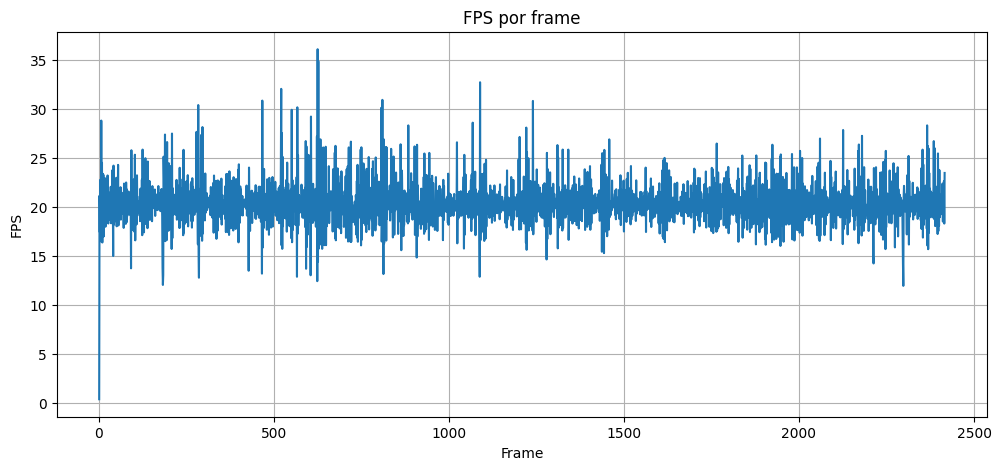

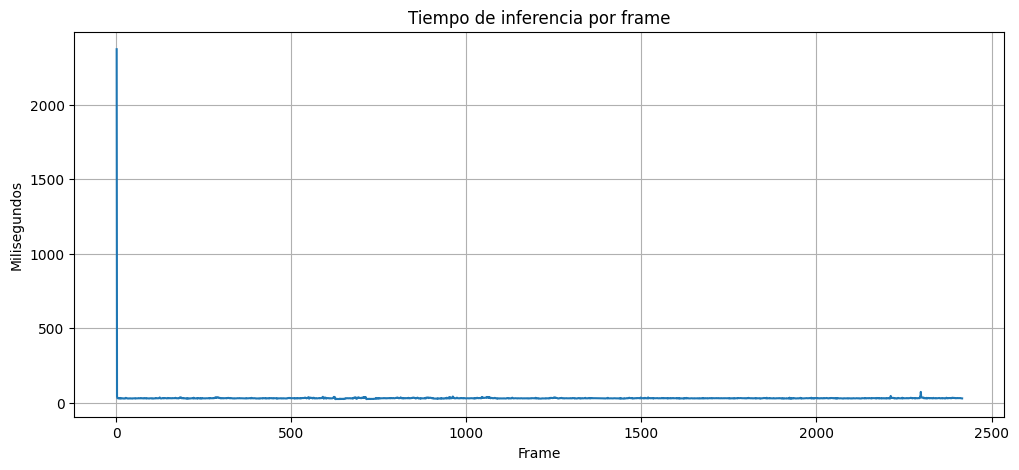

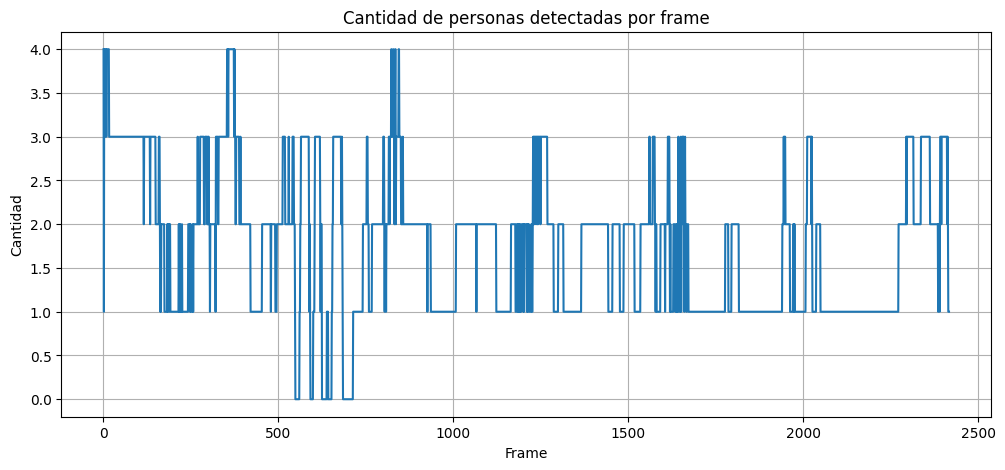

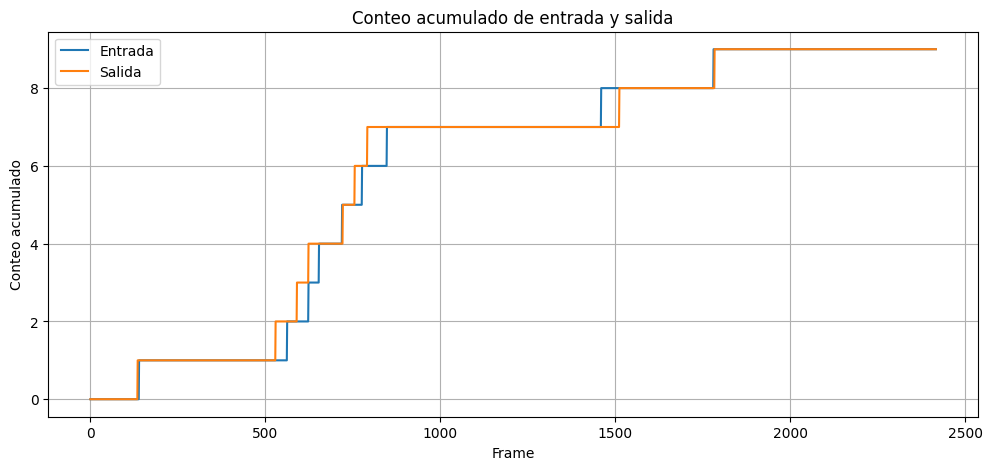

In [13]:
# ==========================================================
# CELDA 13: Visualización de métricas
# Curvas para FPS, inferencia, personas y conteos
# ==========================================================

if not df_metricas.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["fps"])
    plt.title("FPS por frame")
    plt.xlabel("Frame")
    plt.ylabel("FPS")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["tiempo_inferencia_ms"])
    plt.title("Tiempo de inferencia por frame")
    plt.xlabel("Frame")
    plt.ylabel("Milisegundos")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["cantidad_personas"])
    plt.title("Cantidad de personas detectadas por frame")
    plt.xlabel("Frame")
    plt.ylabel("Cantidad")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(df_metricas["frame_id"], df_metricas["conteo_entrada"], label="Entrada")
    plt.plot(df_metricas["frame_id"], df_metricas["conteo_salida"], label="Salida")
    plt.title("Conteo acumulado de entrada y salida")
    plt.xlabel("Frame")
    plt.ylabel("Conteo acumulado")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Sin datos para visualización.")


## Notas de uso

- La tecla **Q** finaliza la captura.
- Para mayor precisión se puede cambiar `MODEL_NAME` a `yolov8s.pt` o `yolov8m.pt`.
- El conteo depende de la posición de la línea.  
- La grabación se almacena en `salida_deteccion_personas_profesional.mp4`.
- El historial de métricas se almacena en `metricas_deteccion_personas_profesional.csv`.
